# Bad Crop Filter Analysis

**目标**: 分析 bad crop score 过滤前后，Image 的 good rate 变化

**数据说明**:
- **Score 文件**: `bad_crop_score.txt` — 每张图片的 bad crop 分数
- **Label 文件**: `UHRS_Task_lp_quality_labeling_0204_LP200_0131-2_official_ZImage_images_cfg0_20260201-0426.tsv` — 3个judge对每张图片投票 (FinalDecision: Good/Bad/Fair)

**规则**:
- Label 聚合: 3票中 ≥ 2票 Bad → 该图为 **Bad**，否则为 Non-Bad (Good/Fair)
- Filter 规则: bad_crop_score < 0.1 → 图片通过 (pass)；≥ 0.1 → 被过滤掉 (filtered)
- Good rate = (label为Non-Bad的图片数) / (总图片数)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# 文件路径
SCORE_FILE = r"D:\Data\T2I\ZImage\official\LP200_0131-2_official_ZImage_images_cfg0_20260201-0426\bad_crop_score.txt"
LABEL_FILE = r"D:\Code\ms-image-quality-filters-aether-module-main\QwenFinetune\RawData\UHRS_Task_lp_quality_labeling_0204_LP200_0131-2_official_ZImage_images_cfg0_20260201-0426.tsv"
THRESHOLD = 0.1

## 1. 读取 Bad Crop Score 文件

In [2]:
# 读取 score 文件，格式: "index→full_path\tscore"
score_rows = []
with open(SCORE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split('\t')
        if len(parts) != 2:
            continue
        path_part, score_str = parts
        # path_part 格式: "123→/full/path/to/filename.png"
        if '→' in path_part:
            full_path = path_part.split('→', 1)[1]
        else:
            full_path = path_part
        filename = Path(full_path).name  # 取文件名: e.g. "Internal100100_Prompt1.png"
        score = float(score_str)
        score_rows.append({'lp_id': filename, 'bad_crop_score': score})

df_score = pd.DataFrame(score_rows)
print(f"Score 文件共 {len(df_score)} 条记录")
print(f"Score 范围: min={df_score['bad_crop_score'].min():.4f}, max={df_score['bad_crop_score'].max():.4f}, mean={df_score['bad_crop_score'].mean():.4f}")
df_score.head()

Score 文件共 1000 条记录
Score 范围: min=0.0180, max=0.6895, mean=0.0585


,lp_id,bad_crop_score
0,Internal100100_Prompt1.png,0.038025
1,Internal100100_Prompt2.png,0.024948
2,Internal100100_Prompt3.png,0.023651
3,Internal100100_Prompt4.png,0.021408
4,Internal100100_Prompt5.png,0.024429


## 2. 读取 Label 文件并聚合投票

In [3]:
# 读取 UHRS label 文件
df_label = pd.read_csv(LABEL_FILE, sep='\t', dtype=str)
print(f"Label 文件共 {len(df_label)} 行（每张图片3个judge投票）")
print(f"列名: {df_label.columns.tolist()}")
df_label[['lp_id', 'JudgeID', 'FinalDecision']].head(9)

Label 文件共 3000 行（每张图片3个judge投票）
列名: ['JudgeID', 'HitGroupDataInt', 'HitDataInt', 'HitState', 'HitType', 'Price', 'JudgmentState', 'JudgmentDataInt', 'JudgmentDataIntName', 'JudgmentSubmitTime', 'JudgmentTypeID', 'JudgmentType', 'Consensus', 'TimeSpentOnJudgment', 'HitGroupID', 'HitID', 'lp_id', 'ImageSource', 'FinalUrl', 'ImgUrl', 'JudgmentID', 'OtherComment', 'FinalDecision', 'Imageclarity', 'BrightnessContrastColorSaturation', 'SubjectClarity', 'TextLogoClarity', 'CompositionLayout', 'RealisticPhysicallyPlausible', 'MainSubjectClarityBadOpotion']


,lp_id,JudgeID,FinalDecision
0,Random10046_Prompt5.png,1628038,Fair
1,Internal10082_Prompt4.png,1628038,Good
2,Internal10028_Prompt3.png,1628038,Good
3,Random10044_Prompt4.png,1628038,Good
4,Internal10029_Prompt2.png,1628038,Good
5,Internal10063_Prompt3.png,1628038,Good
6,Random10038_Prompt4.png,1628038,Bad
7,Internal10034_Prompt3.png,1628038,Bad
8,Random10041_Prompt4.png,1628038,Fair


In [4]:
# 查看 FinalDecision 的所有取值
print("FinalDecision 取值分布:")
print(df_label['FinalDecision'].value_counts())

FinalDecision 取值分布:
FinalDecision
Good             1867
Bad               605
Fair              525
Imageloadfail       2
Logo                1
Name: count, dtype: int64


In [8]:
# 统一大小写
df_label['FinalDecision_norm'] = df_label['FinalDecision'].str.strip().str.lower()

# 每张图片聚合：统计3票中 Bad 的票数
def aggregate_votes(group):
    decisions = group['FinalDecision_norm'].tolist()
    bad_votes = sum(1 for d in decisions if d == 'bad')
    total_votes = len(decisions)
    # ≥2票 bad → 最终为 bad
    final_label = 'bad' if bad_votes >= 2 else 'non-bad'
    return pd.Series({
        'bad_votes': bad_votes,
        'total_votes': total_votes,
        'agg_label': final_label
    })

df_agg = df_label.groupby('lp_id').apply(aggregate_votes).reset_index()
print(f"\n聚合后共 {len(df_agg)} 张图片")
print("\n聚合标签分布:")
print(df_agg['agg_label'].value_counts())
print("\n投票分布 (bad_votes):")
print(df_agg['bad_votes'].value_counts().sort_index())


聚合后共 1000 张图片

聚合标签分布:
agg_label
non-bad    863
bad        137
Name: count, dtype: int64

投票分布 (bad_votes):
bad_votes
0    555
1    308
2    114
3     23
Name: count, dtype: int64


## 3. 合并 Score 与 Label

In [9]:
df = pd.merge(df_score, df_agg[['lp_id', 'bad_votes', 'total_votes', 'agg_label']], on='lp_id', how='inner')
print(f"合并后共 {len(df)} 张图片")
print(f"Score 文件独有（未匹配）: {len(df_score) - len(df)} 张")
print(f"Label 文件独有（未匹配）: {len(df_agg) - len(df)} 张")
df.head()

合并后共 1000 张图片
Score 文件独有（未匹配）: 0 张
Label 文件独有（未匹配）: 0 张


,lp_id,bad_crop_score,bad_votes,total_votes,agg_label
0,Internal100100_Prompt1.png,0.038025,3,3,bad
1,Internal100100_Prompt2.png,0.024948,1,3,non-bad
2,Internal100100_Prompt3.png,0.023651,0,3,non-bad
3,Internal100100_Prompt4.png,0.021408,2,3,bad
4,Internal100100_Prompt5.png,0.024429,1,3,non-bad


## 4. 计算 Filter 前后 Good Rate

In [10]:
# Filter 规则: bad_crop_score < threshold → pass（保留）
df['pass_filter'] = df['bad_crop_score'] < THRESHOLD

# Good rate 定义: agg_label != 'bad' 的比例（即 non-bad rate）
total = len(df)
good_before = (df['agg_label'] == 'non-bad').sum()
good_rate_before = good_before / total

df_filtered = df[df['pass_filter']]
total_after = len(df_filtered)
good_after = (df_filtered['agg_label'] == 'non-bad').sum()
good_rate_after = good_after / total_after if total_after > 0 else 0

filtered_out = total - total_after
filter_rate = filtered_out / total

print("=" * 55)
print(f"  Bad Crop Threshold: {THRESHOLD}")
print("=" * 55)
print(f"  【Filter 前】")
print(f"    总图片数:        {total}")
print(f"    Non-Bad (Good/Fair) 数: {good_before}")
print(f"    Bad 数:          {total - good_before}")
print(f"    Good Rate:       {good_rate_before:.2%}")
print("-" * 55)
print(f"  【Filter 后】 (score < {THRESHOLD} 保留)")
print(f"    过滤掉图片数:    {filtered_out} ({filter_rate:.2%})")
print(f"    剩余图片数:      {total_after}")
print(f"    Non-Bad (Good/Fair) 数: {good_after}")
print(f"    Bad 数:          {total_after - good_after}")
print(f"    Good Rate:       {good_rate_after:.2%}")
print("-" * 55)
print(f"  Good Rate 提升:    +{(good_rate_after - good_rate_before):.2%}")
print("=" * 55)

  Bad Crop Threshold: 0.1
  【Filter 前】
    总图片数:        1000
    Non-Bad (Good/Fair) 数: 863
    Bad 数:          137
    Good Rate:       86.30%
-------------------------------------------------------
  【Filter 后】 (score < 0.1 保留)
    过滤掉图片数:    108 (10.80%)
    剩余图片数:      892
    Non-Bad (Good/Fair) 数: 786
    Bad 数:          106
    Good Rate:       88.12%
-------------------------------------------------------
  Good Rate 提升:    +1.82%


## 5. 分析被过滤图片的 Label 分布

In [11]:
df_filtered_out = df[~df['pass_filter']]

print(f"被过滤掉的图片 (score >= {THRESHOLD}): {len(df_filtered_out)} 张")
print("\n被过滤图片的 label 分布:")
print(df_filtered_out['agg_label'].value_counts())

if len(df_filtered_out) > 0:
    bad_in_filtered = (df_filtered_out['agg_label'] == 'bad').sum()
    print(f"\n其中 Bad 图片: {bad_in_filtered} 张 ({bad_in_filtered/len(df_filtered_out):.2%})")
    print(f"其中 Non-Bad 图片: {len(df_filtered_out)-bad_in_filtered} 张 ({(len(df_filtered_out)-bad_in_filtered)/len(df_filtered_out):.2%})")

被过滤掉的图片 (score >= 0.1): 108 张

被过滤图片的 label 分布:
agg_label
non-bad    77
bad        31
Name: count, dtype: int64

其中 Bad 图片: 31 张 (28.70%)
其中 Non-Bad 图片: 77 张 (71.30%)


## 6. Score 分布可视化

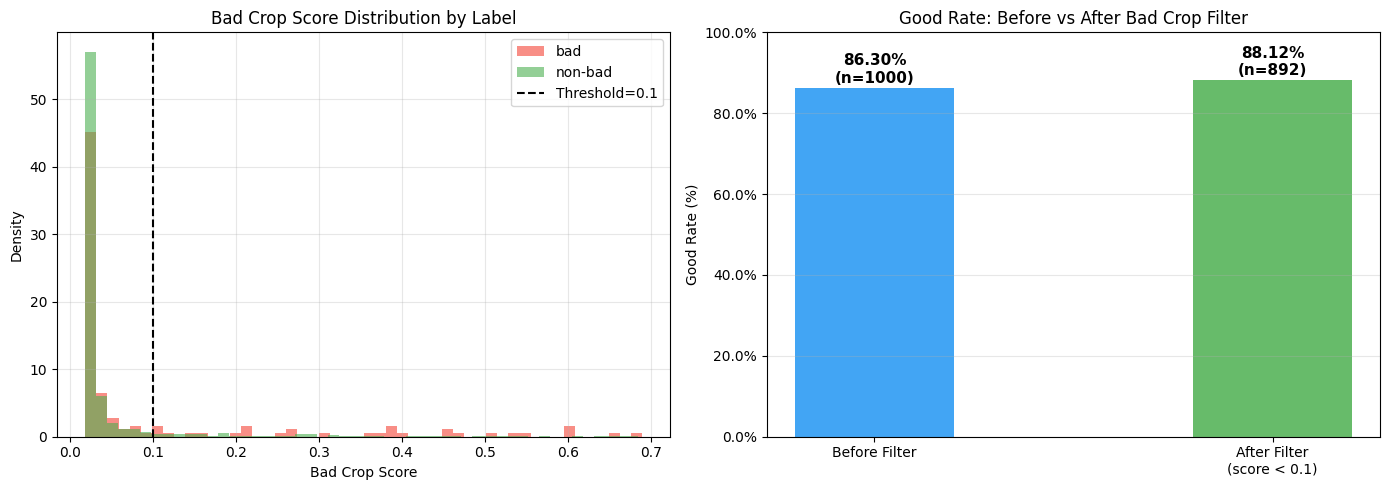

图表已保存为 bad_crop_filter_analysis.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: score 分布，按 label 着色
ax = axes[0]
colors = {'non-bad': '#4CAF50', 'bad': '#F44336'}
for label, grp in df.groupby('agg_label'):
    ax.hist(grp['bad_crop_score'], bins=50, alpha=0.6,
            label=label, color=colors.get(label, 'gray'), density=True)
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={THRESHOLD}')
ax.set_xlabel('Bad Crop Score')
ax.set_ylabel('Density')
ax.set_title('Bad Crop Score Distribution by Label')
ax.legend()
ax.grid(alpha=0.3)

# 右图: filter 前后 good rate 对比
ax2 = axes[1]
categories = ['Before Filter', f'After Filter\n(score < {THRESHOLD})']
rates = [good_rate_before, good_rate_after]
counts = [total, total_after]
bars = ax2.bar(categories, [r * 100 for r in rates], color=['#2196F3', '#4CAF50'], width=0.4, alpha=0.85)
for bar, rate, count in zip(bars, rates, counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{rate:.2%}\n(n={count})', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel('Good Rate (%)')
ax2.set_title('Good Rate: Before vs After Bad Crop Filter')
ax2.set_ylim(0, min(100, max(rates) * 100 * 1.15))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bad_crop_filter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存为 bad_crop_filter_analysis.png")

## 7. 不同 Threshold 下 Good Rate 变化（敏感性分析）

In [13]:
thresholds = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
results = []
for thr in thresholds:
    df_pass = df[df['bad_crop_score'] < thr]
    n = len(df_pass)
    n_good = (df_pass['agg_label'] == 'non-bad').sum()
    good_rate = n_good / n if n > 0 else 0
    results.append({
        'threshold': thr,
        'remaining_images': n,
        'filter_rate': f"{(total - n) / total:.2%}",
        'good_images': n_good,
        'good_rate': f"{good_rate:.2%}"
    })

df_results = pd.DataFrame(results)
print("不同 threshold 下的 Good Rate:")
print(df_results.to_string(index=False))

不同 threshold 下的 Good Rate:
 threshold  remaining_images filter_rate  good_images good_rate
      0.05               836      16.40%          740    88.52%
      0.08               879      12.10%          775    88.17%
      0.10               892      10.80%          786    88.12%
      0.12               906       9.40%          796    87.86%
      0.15               915       8.50%          804    87.87%
      0.20               931       6.90%          819    87.97%
      0.25               943       5.70%          826    87.59%
      0.30               954       4.60%          835    87.53%
      0.40               968       3.20%          843    87.09%
      0.50               979       2.10%          850    86.82%
